# MedGemma Batch Validation

Runs `python main.py <variant>` for every variant in `clinvar_latest.csv`,
parses the resulting HTML tissue stats, and compares them against ClinVar `cardiac` / `muscular` ground truth.

**Checkpoint**: results are saved to `outputs/medgemma_validation_checkpoint.csv` after every variant.
Re-running the notebook safely resumes from where it left off.

**Config cells** — adjust `VARIANT_FILTER` and `MAX_VARIANTS` before running.

In [11]:
from pathlib import Path
import re, subprocess, sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from bs4 import BeautifulSoup

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (8, 6)

# ── Paths ────────────────────────────────────────────────────────────────────
PROJECT_DIR     = Path('/home/ryan910702/ttn-agent')
CLINVAR_PATH    = PROJECT_DIR / 'data' / 'clinvar_latest.csv'
OUTPUTS_DIR     = PROJECT_DIR / 'outputs'
CHECKPOINT_PATH = OUTPUTS_DIR / 'medgemma_validation_checkpoint.csv'
PYTHON_BIN      = '/home/ryan910702/miniconda3/envs/new/bin/python3'

# ── Run config ───────────────────────────────────────────────────────────────
# Which variants to run main.py on (in addition to already-existing HTMLs)
# Options: 'pathogenic', 'benign', 'all'
VARIANT_FILTER = 'pathogenic'

# Maximum number of NEW variants to run main.py on in this session
# Set to None to run all
MAX_VARIANTS = None

# Timeout per variant (seconds) — main.py can take 10-30 min with MedGemma
TIMEOUT = 3600  # 60 minutes

OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)
print(f'Project dir : {PROJECT_DIR}')
print(f'Checkpoint  : {CHECKPOINT_PATH}')
print(f'Filter      : {VARIANT_FILTER}')
print(f'Max new runs: {MAX_VARIANTS}')

Project dir : /home/ryan910702/ttn-agent
Checkpoint  : /home/ryan910702/ttn-agent/outputs/medgemma_validation_checkpoint.csv
Filter      : pathogenic
Max new runs: None


## Step 1 — Load ClinVar Ground Truth

In [12]:
df_cv = pd.read_csv(CLINVAR_PATH)

# Normalise label
def normalize_label(text):
    t = str(text).lower()
    if 'pathogenic' in t and 'benign' not in t:
        return 'pathogenic'
    if 'benign' in t:
        return 'benign'
    return 'uncertain'

df_cv['clinvar_label'] = df_cv['Germline classification'].map(normalize_label)
df_cv['position']      = pd.to_numeric(df_cv['position'], errors='coerce').astype('Int64')
df_cv = df_cv.dropna(subset=['position', 'ref', 'alt']).copy()
df_cv['position'] = df_cv['position'].astype(int)
df_cv['variant_id'] = (
    df_cv['chr'].astype(str) + '-' +
    df_cv['position'].astype(str) + '-' +
    df_cv['ref'].astype(str) + '-' +
    df_cv['alt'].astype(str)
)
# Dominant phenotype from ClinVar cardiac/muscular counts
def dominant(a, b):
    if a > b:  return 'cardiac'
    if b > a:  return 'muscular'
    return 'mixed'

df_cv['cv_dominant'] = df_cv.apply(
    lambda r: dominant(r['cardiac'], r['muscular']), axis=1
)

print(f'Total variants : {len(df_cv)}')
print(df_cv['clinvar_label'].value_counts())
print('\ncv_dominant distribution:')
print(df_cv['cv_dominant'].value_counts())

Total variants : 4990
clinvar_label
benign        4357
pathogenic     633
Name: count, dtype: int64

cv_dominant distribution:
cv_dominant
mixed       2953
muscular    1968
cardiac       69
Name: count, dtype: int64


## Step 2 — Load Checkpoint + Scan Existing HTMLs

In [13]:
def parse_html_report(html_path: Path) -> dict | None:
    """Extract tissue counts from an HTML report. Returns None if parsing fails."""
    try:
        with open(html_path, encoding='utf-8') as f:
            soup = BeautifulSoup(f, 'html.parser')

        title = soup.title.string if soup.title else ''
        m = re.search(r'(\d+-\d+-[A-Z]+-[A-Z]+)', title)
        if not m:
            return None
        variant_id = m.group(1)

        lines = [l.strip() for l in soup.get_text().split('\n') if l.strip()]

        def extract_count(label):
            for i, line in enumerate(lines):
                if line == label and i + 1 < len(lines):
                    nm = re.match(r'(\d+)\s+article', lines[i + 1])
                    if nm:
                        return int(nm.group(1))
            return None

        total = None
        for line in lines:
            tm = re.search(r'Literature Review \((\d+) articles\)', line)
            if tm:
                total = int(tm.group(1))
                break

        cardiac  = extract_count('Cardiac')
        skeletal = extract_count('Skeletal')
        both     = extract_count('Both')
        not_spec = extract_count('Not Specified')

        if cardiac is None:  # tissue stats block not found
            return None

        return {
            'variant_id':     variant_id,
            'total_articles': total,
            'mg_cardiac':     cardiac,
            'mg_skeletal':    skeletal,
            'mg_both':        both,
            'mg_not_spec':    not_spec,
            'html_file':      html_path.name,
        }
    except Exception as e:
        print(f'  Parse error {html_path.name}: {e}')
        return None


# ── Load checkpoint ───────────────────────────────────────────────────────────
if CHECKPOINT_PATH.exists():
    ckpt_df = pd.read_csv(CHECKPOINT_PATH)
    done_ids = set(ckpt_df['variant_id'])
    print(f'Checkpoint loaded: {len(ckpt_df)} variants already processed')
else:
    ckpt_df  = pd.DataFrame()
    done_ids = set()
    print('No checkpoint found — starting from scratch')

# ── Scan existing HTML files ──────────────────────────────────────────────────
print('\nScanning existing HTML reports...')
new_from_html = []
for html_path in sorted(OUTPUTS_DIR.glob('*.html')):
    parsed = parse_html_report(html_path)
    if parsed and parsed['variant_id'] not in done_ids:
        new_from_html.append(parsed)
        done_ids.add(parsed['variant_id'])

if new_from_html:
    # Join with ClinVar ground truth and add to checkpoint
    new_html_df = pd.DataFrame(new_from_html)
    # Keep best HTML per variant (most articles)
    new_html_df = (
        new_html_df
        .sort_values('total_articles', ascending=False)
        .drop_duplicates('variant_id', keep='first')
    )
    cv_lookup = df_cv.set_index('variant_id')[['clinvar_label','cardiac','muscular','cv_dominant','Germline classification','Condition(s)']]
    new_html_df = new_html_df.join(cv_lookup, on='variant_id', how='left')
    new_html_df['status'] = 'success_existing_html'
    ckpt_df = pd.concat([ckpt_df, new_html_df], ignore_index=True)
    ckpt_df.to_csv(CHECKPOINT_PATH, index=False)
    print(f'  Added {len(new_html_df)} variants from existing HTMLs → checkpoint saved')
else:
    print('  No new HTMLs found')

print(f'\nTotal in checkpoint now: {len(ckpt_df)}')

No checkpoint found — starting from scratch

Scanning existing HTML reports...
  Added 213 variants from existing HTMLs → checkpoint saved

Total in checkpoint now: 213


## Step 3 — Run `main.py` for Remaining Variants

In [14]:
# Select variants to run
if VARIANT_FILTER == 'all':
    run_df = df_cv.copy()
else:
    run_df = df_cv[df_cv['clinvar_label'] == VARIANT_FILTER].copy()

# Exclude already done
run_df = run_df[~run_df['variant_id'].isin(done_ids)].reset_index(drop=True)

if MAX_VARIANTS is not None:
    run_df = run_df.head(MAX_VARIANTS)

print(f'Variants to run: {len(run_df)}')
print(run_df[['variant_id', 'clinvar_label', 'cv_dominant']].head(10))

Variants to run: 433
        variant_id clinvar_label cv_dominant
0  2-178528821-G-T    pathogenic     cardiac
1  2-178537711-G-T    pathogenic     cardiac
2  2-178537806-G-A    pathogenic       mixed
3  2-178539012-C-T    pathogenic     cardiac
4  2-178552194-G-T    pathogenic       mixed
5  2-178554071-G-A    pathogenic     cardiac
6  2-178563607-C-T    pathogenic    muscular
7  2-178563662-G-A    pathogenic       mixed
8  2-178563859-C-T    pathogenic       mixed
9  2-178563892-C-T    pathogenic       mixed


In [15]:
cv_lookup = df_cv.set_index('variant_id')[
    ['clinvar_label', 'cardiac', 'muscular', 'cv_dominant',
     'Germline classification', 'Condition(s)']
]

model_name_short = 'medgemma-27b-it'   # must match config.py LOCAL_LLM_MODEL suffix

for i, (_, row) in enumerate(run_df.iterrows()):
    vid = row['variant_id']
    expected_html = OUTPUTS_DIR / f'{vid}_{model_name_short}.html'

    print(f'[{i+1}/{len(run_df)}] {vid} ...', end=' ', flush=True)

    result_row = {
        'variant_id':              vid,
        'clinvar_label':           row['clinvar_label'],
        'cardiac':                 row['cardiac'],
        'muscular':                row['muscular'],
        'cv_dominant':             row['cv_dominant'],
        'Germline classification': row['Germline classification'],
        'Condition(s)':            row['Condition(s)'],
        'total_articles':          None,
        'mg_cardiac':              None,
        'mg_skeletal':             None,
        'mg_both':                 None,
        'mg_not_spec':             None,
        'html_file':               None,
        'status':                  'pending',
    }

    # ── Run main.py ──────────────────────────────────────────────────────────
    try:
        proc = subprocess.run(
            [PYTHON_BIN, str(PROJECT_DIR / 'main.py'), vid],
            cwd=str(PROJECT_DIR),
            capture_output=True,
            text=True,
            timeout=TIMEOUT,
        )
        if proc.returncode != 0:
            print(f'FAILED (exit {proc.returncode})')
            result_row['status'] = f'error_exit_{proc.returncode}'
            print('  stderr:', proc.stderr[-300:] if proc.stderr else '(none)')
        else:
            print('OK', end=' ')
            result_row['status'] = 'success'
    except subprocess.TimeoutExpired:
        print(f'TIMEOUT ({TIMEOUT}s)')
        result_row['status'] = 'timeout'
    except Exception as e:
        print(f'ERROR: {e}')
        result_row['status'] = f'error: {e}'

    # ── Parse HTML output ─────────────────────────────────────────────────────
    if result_row['status'] == 'success':
        # Find the HTML — may have a different model suffix; scan outputs dir
        matching_htmls = sorted(
            OUTPUTS_DIR.glob(f'{vid}_*.html'),
            key=lambda p: p.stat().st_mtime,
            reverse=True,
        )
        if matching_htmls:
            parsed = parse_html_report(matching_htmls[0])
            if parsed:
                result_row.update({
                    'total_articles': parsed['total_articles'],
                    'mg_cardiac':     parsed['mg_cardiac'],
                    'mg_skeletal':    parsed['mg_skeletal'],
                    'mg_both':        parsed['mg_both'],
                    'mg_not_spec':    parsed['mg_not_spec'],
                    'html_file':      parsed['html_file'],
                })
                print(f'→ cardiac={parsed["mg_cardiac"]} skeletal={parsed["mg_skeletal"]} not_spec={parsed["mg_not_spec"]}')
            else:
                print('→ HTML parse failed')
                result_row['status'] = 'error_html_parse'
        else:
            print('→ HTML not found')
            result_row['status'] = 'error_no_html'

    # ── Append to checkpoint ──────────────────────────────────────────────────
    new_row = pd.DataFrame([result_row])
    ckpt_df = pd.concat([ckpt_df, new_row], ignore_index=True)
    ckpt_df.to_csv(CHECKPOINT_PATH, index=False)
    done_ids.add(vid)

print(f'\nDone. Checkpoint has {len(ckpt_df)} entries.')

[1/433] 2-178528821-G-T ... 

OK → HTML parse failed
[2/433] 2-178537711-G-T ... OK → HTML parse failed
[3/433] 2-178537806-G-A ... OK → HTML parse failed
[4/433] 2-178539012-C-T ... OK → HTML parse failed
[5/433] 2-178552194-G-T ... OK → HTML parse failed
[6/433] 2-178554071-G-A ... OK → HTML parse failed
[7/433] 2-178563607-C-T ... OK → cardiac=0 skeletal=0 not_spec=6
[8/433] 2-178563662-G-A ... OK → cardiac=0 skeletal=0 not_spec=3
[9/433] 2-178563859-C-T ... OK → cardiac=0 skeletal=0 not_spec=4
[10/433] 2-178563892-C-T ... OK → cardiac=0 skeletal=0 not_spec=8
[11/433] 2-178563924-C-G ... OK → cardiac=0 skeletal=0 not_spec=2
[12/433] 2-178563948-T-A ... OK → cardiac=0 skeletal=0 not_spec=2
[13/433] 2-178563960-G-A ... OK → cardiac=0 skeletal=0 not_spec=3
[14/433] 2-178564096-C-T ... OK → cardiac=0 skeletal=0 not_spec=12
[15/433] 2-178564144-C-T ... OK → cardiac=0 skeletal=0 not_spec=1
[16/433] 2-178564189-G-T ... OK → cardiac=0 skeletal=0 not_spec=3
[17/433] 2-178564206-G-A ... OK → cardiac=0 skeletal=0 not_spec=

## Step 4 — Compute Metrics

In [16]:
# Load checkpoint (all sessions combined)
ckpt_df = pd.read_csv(CHECKPOINT_PATH)
print(f'Total checkpoint entries : {len(ckpt_df)}')
print(f'Status distribution:')
print(ckpt_df['status'].value_counts())

# Keep only successfully parsed entries
result_df = ckpt_df[ckpt_df['mg_cardiac'].notna()].copy()
result_df['mg_cardiac']  = result_df['mg_cardiac'].astype(int)
result_df['mg_skeletal'] = result_df['mg_skeletal'].astype(int)
result_df['mg_both']     = result_df['mg_both'].astype(int)
result_df['mg_not_spec'] = result_df['mg_not_spec'].astype(int)
result_df['cardiac']     = result_df['cardiac'].astype(int)
result_df['muscular']    = result_df['muscular'].astype(int)

def dominant(a, b):
    if a > b:  return 'cardiac'
    if b > a:  return 'muscular'
    return 'mixed'

result_df['mg_dominant'] = result_df.apply(
    lambda r: dominant(r['mg_cardiac'], r['mg_skeletal']), axis=1
)
result_df['agree'] = result_df['cv_dominant'] == result_df['mg_dominant']

print(f'\nVariants with parsed HTML : {len(result_df)}')
print(f'Overall agreement         : {result_df["agree"].sum()}/{len(result_df)} = {result_df["agree"].mean():.1%}')

Total checkpoint entries : 646
Status distribution:
status
success                  416
success_existing_html    213
error_html_parse          17
Name: count, dtype: int64


IntCastingNaNError: Cannot convert non-finite values (NA or inf) to integer.Replace or remove non-finite values or cast to an integer typethat supports these values (e.g. 'Int64')

## Step 5 — Confusion Matrix

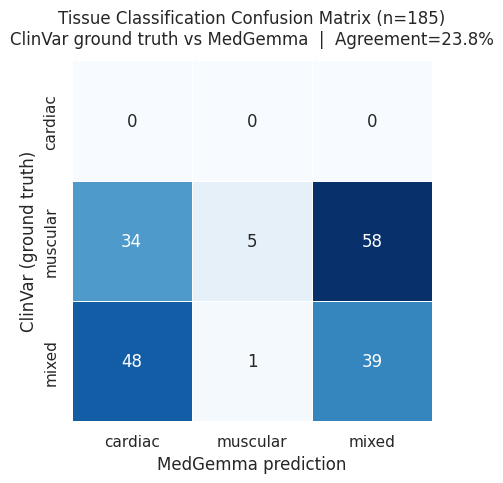


Per-class accuracy:
  muscular: 5.2%  (n=97)
  mixed   : 44.3%  (n=88)


In [ ]:
categories = ['cardiac', 'muscular', 'mixed']
cm_data = pd.crosstab(
    result_df['cv_dominant'],
    result_df['mg_dominant'],
    rownames=['ClinVar (ground truth)'],
    colnames=['MedGemma prediction'],
).reindex(index=categories, columns=categories, fill_value=0)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_data, annot=True, fmt='d', cmap='Blues',
            linewidths=0.5, square=True, cbar=False, ax=ax)
ax.set_title(
    f'Tissue Classification Confusion Matrix (n={len(result_df)})\n'
    f'ClinVar ground truth vs MedGemma  |  Agreement={result_df["agree"].mean():.1%}',
    pad=12
)
plt.tight_layout()
plt.show()

# Per-class accuracy
print('\nPer-class accuracy:')
for cat in categories:
    sub = result_df[result_df['cv_dominant'] == cat]
    if len(sub):
        acc = (sub['mg_dominant'] == cat).mean()
        print(f'  {cat:8s}: {acc:.1%}  (n={len(sub)})')

## Step 6 — Cardiac Fraction Scatter

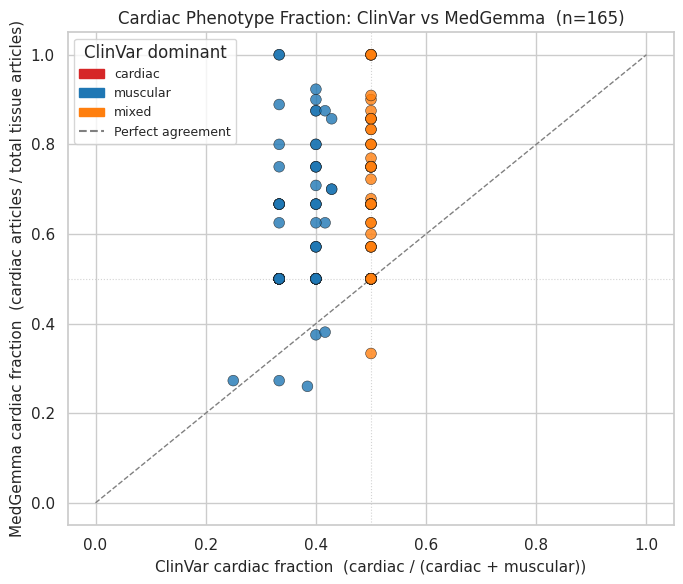

In [ ]:
denom_cv = (result_df['cardiac'] + result_df['muscular']).replace(0, np.nan)
result_df['cv_cardiac_frac'] = result_df['cardiac'] / denom_cv

denom_mg = (result_df['mg_cardiac'] + result_df['mg_skeletal'] + result_df['mg_both']).replace(0, np.nan)
result_df['mg_cardiac_frac'] = (result_df['mg_cardiac'] + 0.5 * result_df['mg_both']) / denom_mg

plot_df = result_df.dropna(subset=['cv_cardiac_frac', 'mg_cardiac_frac']).copy()

color_map = {'cardiac': '#d62728', 'muscular': '#1f77b4', 'mixed': '#ff7f0e'}
colors = plot_df['cv_dominant'].map(color_map)

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(plot_df['cv_cardiac_frac'], plot_df['mg_cardiac_frac'],
           c=colors, s=60, edgecolors='k', linewidths=0.4, alpha=0.8, zorder=3)
ax.plot([0, 1], [0, 1], '--', color='gray', linewidth=1)
ax.axhline(0.5, color='lightgray', linewidth=0.8, linestyle=':')
ax.axvline(0.5, color='lightgray', linewidth=0.8, linestyle=':')

handles = [mpatches.Patch(color=c, label=l) for l, c in color_map.items()]
handles.append(plt.Line2D([0], [0], linestyle='--', color='gray', label='Perfect agreement'))
ax.legend(handles=handles, title='ClinVar dominant', fontsize=9)
ax.set_xlabel('ClinVar cardiac fraction  (cardiac / (cardiac + muscular))', fontsize=11)
ax.set_ylabel('MedGemma cardiac fraction  (cardiac articles / total tissue articles)', fontsize=11)
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.05, 1.05)
ax.set_title(f'Cardiac Phenotype Fraction: ClinVar vs MedGemma  (n={len(plot_df)})', fontsize=12)
plt.tight_layout()
plt.show()

## Step 7 — Extraction Quality (Not-Specified Rate)

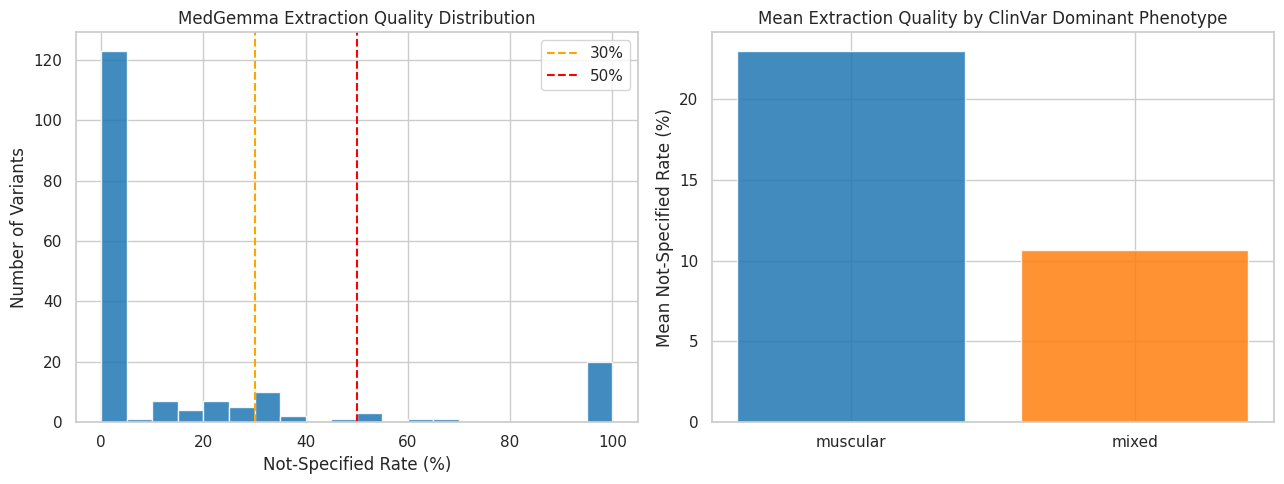

Mean not-specified rate  : 17.1%
Median not-specified rate: 0.0%
> 50% not-specified      : 22 variants


In [ ]:
result_df['mg_not_spec_rate'] = (
    result_df['mg_not_spec'] / result_df['total_articles'].replace(0, np.nan)
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Not-specified rate histogram
axes[0].hist(result_df['mg_not_spec_rate'].dropna() * 100, bins=20,
             color='#1f77b4', edgecolor='white', alpha=0.85)
axes[0].axvline(30, color='orange', linestyle='--', linewidth=1.5, label='30%')
axes[0].axvline(50, color='red',    linestyle='--', linewidth=1.5, label='50%')
axes[0].set_xlabel('Not-Specified Rate (%)')
axes[0].set_ylabel('Number of Variants')
axes[0].set_title('MedGemma Extraction Quality Distribution')
axes[0].legend()

# Mean not-specified rate by cv_dominant
grp = result_df.groupby('cv_dominant')['mg_not_spec_rate'].mean() * 100
grp = grp.reindex(['cardiac', 'muscular', 'mixed'])
axes[1].bar(grp.index, grp.values,
            color=['#d62728', '#1f77b4', '#ff7f0e'], alpha=0.85, edgecolor='white')
axes[1].set_ylabel('Mean Not-Specified Rate (%)')
axes[1].set_title('Mean Extraction Quality by ClinVar Dominant Phenotype')

plt.tight_layout()
plt.show()

print(f'Mean not-specified rate  : {result_df["mg_not_spec_rate"].mean():.1%}')
print(f'Median not-specified rate: {result_df["mg_not_spec_rate"].median():.1%}')
print(f'> 50% not-specified      : {(result_df["mg_not_spec_rate"] > 0.5).sum()} variants')

## Step 8 — Agreement by ClinVar Label & Phenotype

,clinvar_label,cv_dominant,n,agree_n,agree_pct
0,benign,muscular,6,0,0.000000
1,pathogenic,mixed,88,39,44.318182
2,pathogenic,muscular,91,5,5.494505


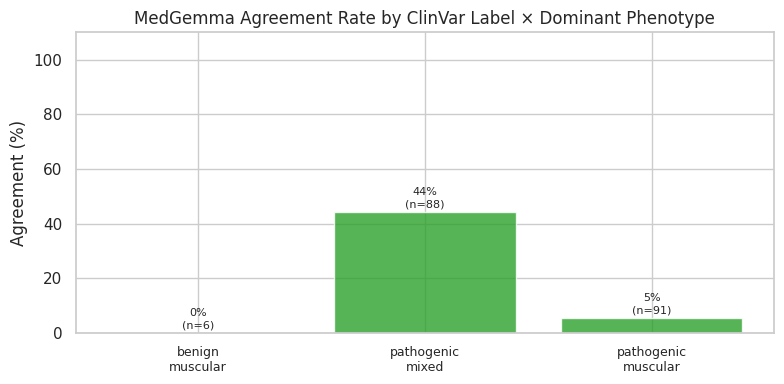

In [ ]:
# Agreement broken down by clinvar_label × cv_dominant
summary = (
    result_df
    .groupby(['clinvar_label', 'cv_dominant'])['agree']
    .agg(n='count', agree_n='sum')
    .assign(agree_pct=lambda d: d['agree_n'] / d['n'] * 100)
    .reset_index()
)
display(summary)

fig, ax = plt.subplots(figsize=(8, 4))
x = range(len(summary))
bars = ax.bar(x, summary['agree_pct'], color='#2ca02c', alpha=0.8)
ax.set_xticks(list(x))
ax.set_xticklabels(
    [f"{r['clinvar_label']}\n{r['cv_dominant']}" for _, r in summary.iterrows()],
    fontsize=9
)
ax.set_ylabel('Agreement (%)')
ax.set_ylim(0, 110)
for bar, (_, r) in zip(bars, summary.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f"{r['agree_pct']:.0f}%\n(n={r['n']})", ha='center', va='bottom', fontsize=8)
ax.set_title('MedGemma Agreement Rate by ClinVar Label × Dominant Phenotype')
plt.tight_layout()
plt.show()

## Step 9 — Save Final Results

In [ ]:
out_path = OUTPUTS_DIR / 'medgemma_validation_results.csv'
result_df.to_csv(out_path, index=False)
print(f'Saved: {out_path}  ({len(result_df)} rows)')

# Summary stats
print(f'\n=== Validation Summary ===')
print(f'Total variants evaluated : {len(result_df)}')
print(f'Overall agreement        : {result_df["agree"].mean():.1%}')
print(f'Mean not-specified rate  : {result_df["mg_not_spec_rate"].mean():.1%}')
print(f'Mean articles/variant    : {result_df["total_articles"].mean():.1f}')
print(f'\nAgreement by cv_dominant:')
for cat in ['cardiac','muscular','mixed']:
    sub = result_df[result_df['cv_dominant'] == cat]
    if len(sub):
        print(f'  {cat:8s}: {sub["agree"].mean():.1%}  (n={len(sub)})')

Saved: /home/ryan910702/ttn-agent/outputs/medgemma_validation_results.csv  (185 rows)

=== Validation Summary ===
Total variants evaluated : 185
Overall agreement        : 23.8%
Mean not-specified rate  : 17.1%
Mean articles/variant    : 5.3

Agreement by cv_dominant:
  muscular: 5.2%  (n=97)
  mixed   : 44.3%  (n=88)
